In [71]:
from pocketgrad.engine import Scalar
from pocketgrad.visualize import draw_graph

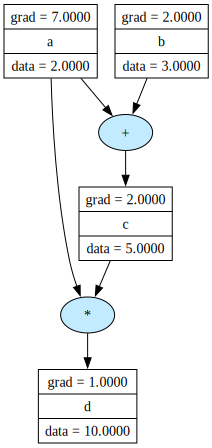

In [72]:
# Our first computational graph
a = Scalar(2.0, label="a")
b = Scalar(3.0, label="b")

c = a + b; c.label = "c"
d = a * c; d.label = "d"

d.backward()
draw_graph(d)

### Symbolic Differentiation with Chain Rule

$a = 2$<br>
$b = 3$<br>
$c = a + b$<br>
$d = a \cdot c$

$d_{\text{grad}} = \dfrac{\partial d}{\partial d} = 1$

$c_{\text{grad}} = \dfrac{\partial d}{\partial c} = \dfrac{\partial (a \cdot c)}{\partial c} = a = 2$

$b_{\text{grad}} = \dfrac{\partial d}{\partial b} = \dfrac{\partial (a \cdot c)}{\partial c} \cdot \dfrac{\partial (a+b)}{\partial b} = 2 \cdot 1 = 2$

$a_{\text{grad}} = \dfrac{\partial d}{\partial a} = \underbrace{\dfrac{\partial (a \cdot c)}{\partial a}}_{\text{path-1}} + \underbrace{\dfrac{\partial (a \cdot c)}{\partial c} \cdot \dfrac{\partial (a+b)}{\partial a}}_{\text{path-2}} = c + a = 5 + 2 = 7$


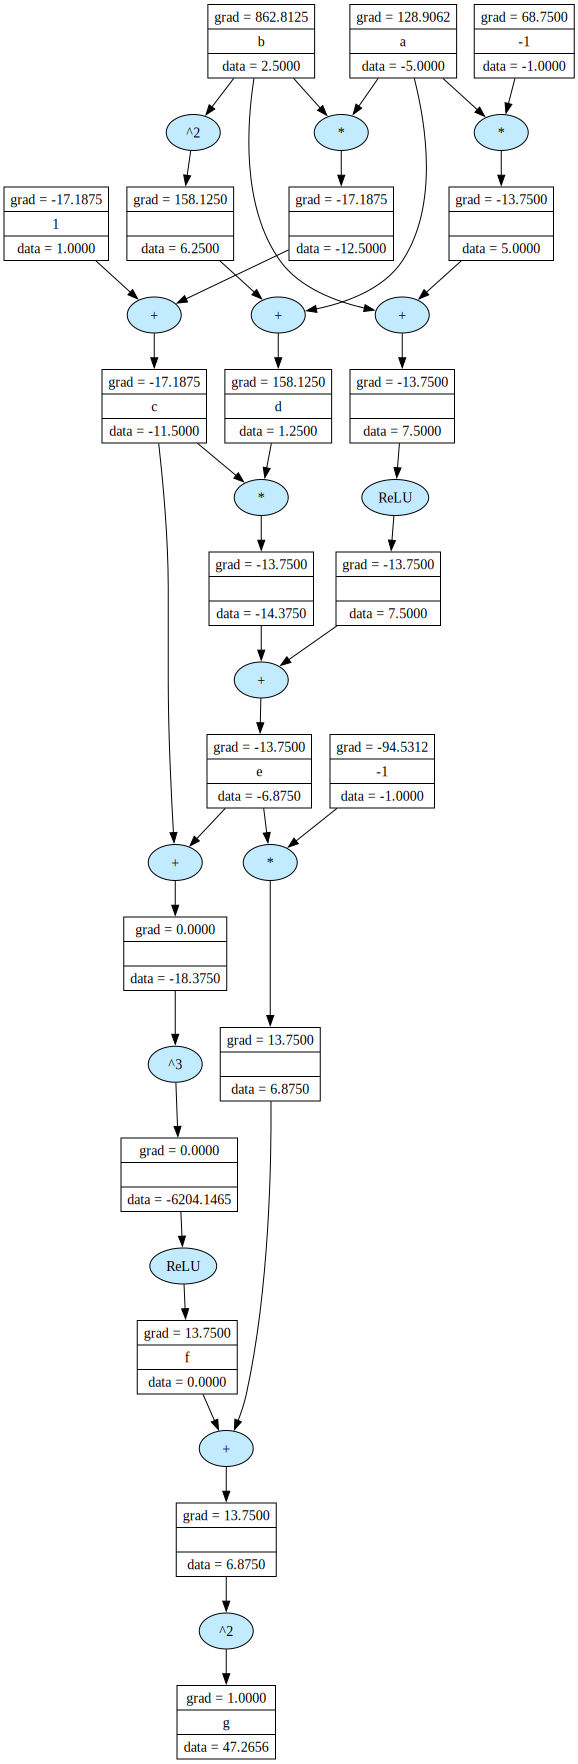

In [73]:
# More complex computational graph
a = Scalar(-5.0, label="a")
b = Scalar(2.5, label="b")

c = a * b + 1;              c.label = "c"
d = a + b**2;               d.label = "d"
e = c * d + (b - a).relu(); e.label = "e"
f = ((e + c) ** 3).relu();  f.label = "f"
g = (f - e) ** 2;           g.label = "g"

g.backward()
draw_graph(g)

<br>$\text{Good luck differentiating this one by hand :)}$